# DiploDatos Kaggle Competition

Grupo 26: Astoreca Pablo, Callen Ailen, Mendez Juan Ignacio, Zamorano Micaela. 


El objetivo de este practico es intentar predecir si una persona puede llegar a tener diabetes en función de ciertos indicadores médicos. Para ello, entrenamos diferentes clasificadores y evaluamos su rendimiento de acuerdo a la metrica recall_score. 

**Los atributos del dataset utilizado son:**

- PacientID: Un numero de identificación de cada paciente

- Gender: Se refiere al sexo biológico de la persona, lo cual puede influir en su susceptibilidad a la diabetes. Tiene tres categorías: male, female y other.

- age: La edad es un factor importante, ya que la diabetes se diagnostica con mayor frecuencia en adultos mayores. En este conjunto de datos, la edad varía entre 0 y 80 años.

- hypertension: Es una condición médica en la que la presión arterial se mantiene elevada de forma persistente. Toma valores 0 o 1, donde 0 indica que la persona no tiene hipertensión y 1 indica que sí la tiene.

- heart_disease: Otra condición médica asociada con un mayor riesgo de desarrollar diabetes. Toma valores 0 o 1, donde 0 indica ausencia de enfermedad cardíaca y 1 indica presencia.

- smoking_history: El historial de tabaquismo también se considera un factor de riesgo para la diabetes y puede agravar sus complicaciones. En el conjunto de datos hay seis categorías: not current, former, No Info, current, never y ever.

- bmi: El índice de masa corporal (IMC) es una medida de grasa corporal basada en el peso y la altura. Valores altos de BMI se asocian a un mayor riesgo de diabetes. El rango en el conjunto de datos va de 10.16 a 71.55. Un BMI menor a 18.5 se considera bajo peso, entre 18.5 y 24.9 es normal, entre 25 y 29.9 es sobrepeso, y 30 o más es obesidad.

- HbA1c_level: Es una medida del nivel promedio de glucosa en sangre durante los últimos 2-3 meses. Niveles elevados indican mayor riesgo de desarrollar diabetes. Generalmente, un valor mayor al 6.5% indica diabetes.

- blood_glucose_level: Se refiere a la cantidad de glucosa presente en la sangre en un momento dado. Niveles altos de glucosa son un indicador clave de diabetes.

- diabetes: Es la variable objetivo que se busca predecir, donde un valor de 1 indica presencia de diabetes y 0 indica ausencia.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.metrics import recall_score, ConfusionMatrixDisplay, classification_report

from sklearn.tree import DecisionTreeClassifier


## Leer el dataset

### Train

Cargamos los datos de entrenamiento que vamos a utilizar para generar nuestro modelo.

In [2]:
train_df = pd.read_csv('diabetes_prediction_dataset_train-labeled.csv')
print(train_df.shape)
print(train_df.describe())

(95000, 10)
             patient           age  hypertension  heart_disease           bmi  \
count   95000.000000  95000.000000  95000.000000   95000.000000  95000.000000   
mean    50016.501389     41.935269      0.075074       0.039463     27.320879   
std     28868.357071     22.514788      0.263512       0.194695      6.626335   
min         1.000000      0.080000      0.000000       0.000000     10.010000   
25%     25021.750000     24.000000      0.000000       0.000000     23.650000   
50%     50024.000000     43.000000      0.000000       0.000000     27.320000   
75%     75024.250000     60.000000      0.000000       0.000000     29.580000   
max    100000.000000     80.000000      1.000000       1.000000     95.690000   

        HbA1c_level  blood_glucose_level      diabetes  
count  95000.000000         95000.000000  95000.000000  
mean       5.527659           138.070537      0.085074  
std        1.070261            40.739962      0.278993  
min        3.500000           

In [3]:
train_df.head()

,patient,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,20432,Male,4.0,0,0,never,19.28,3.5,155,0
1,49682,Female,50.0,0,0,former,27.32,5.7,159,0
2,73886,Female,43.0,0,0,never,21.54,4.5,145,0
3,53144,Male,64.0,0,0,current,28.22,6.0,130,0
4,98507,Male,10.0,0,0,No Info,15.46,6.1,140,0


In [4]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 95000 entries, 0 to 94999
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   patient              95000 non-null  int64  
 1   gender               95000 non-null  object 
 2   age                  95000 non-null  float64
 3   hypertension         95000 non-null  int64  
 4   heart_disease        95000 non-null  int64  
 5   smoking_history      95000 non-null  object 
 6   bmi                  95000 non-null  float64
 7   HbA1c_level          95000 non-null  float64
 8   blood_glucose_level  95000 non-null  int64  
 9   diabetes             95000 non-null  int64  
dtypes: float64(3), int64(5), object(2)
memory usage: 7.2+ MB


La columna ***`diabetes`*** es la columna que debemos predecir. En el dataset de Test esta columna tiene valores nulos.

### Test

Cargamos los datos de test. Estos datos son los que van a utilizar para predecir si las personas tienen diabetes y generar el archivo `submision.csv` para utilizar en la competencia de Kaggle.

In [5]:
test_df = pd.read_csv('diabetes_prediction_dataset_test.csv')
print(test_df.shape)
print(test_df.describe())

(5000, 10)
            patient          age  hypertension  heart_disease          bmi  \
count   5000.000000  5000.000000   5000.000000    5000.000000  5000.000000   
mean   49696.473600    40.947016      0.070600       0.038600    27.318644   
std    28855.568156    22.537466      0.256181       0.192659     6.832943   
min        7.000000     0.160000      0.000000       0.000000    10.620000   
25%    24720.750000    23.000000      0.000000       0.000000    23.410000   
50%    49522.500000    41.000000      0.000000       0.000000    27.320000   
75%    74686.000000    59.000000      0.000000       0.000000    29.632500   
max    99970.000000    80.000000      1.000000       1.000000    88.760000   

       HbA1c_level  blood_glucose_level  diabetes  
count  5000.000000          5000.000000       0.0  
mean      5.524620           137.821000       NaN  
std       1.078559            40.101933       NaN  
min       3.500000            80.000000       NaN  
25%       4.800000        

In [6]:
test_df.head()

,patient,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,49267,Male,53.0,0,0,never,31.99,4.5,126,NaN
1,82280,Female,22.0,0,0,never,25.96,6.6,130,NaN
2,33216,Female,37.0,0,0,never,22.24,6.2,126,NaN
3,94551,Female,29.0,0,0,not current,31.01,5.0,80,NaN
4,43760,Male,30.0,0,0,ever,28.66,6.6,100,NaN


In [7]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   patient              5000 non-null   int64  
 1   gender               5000 non-null   object 
 2   age                  5000 non-null   float64
 3   hypertension         5000 non-null   int64  
 4   heart_disease        5000 non-null   int64  
 5   smoking_history      5000 non-null   object 
 6   bmi                  5000 non-null   float64
 7   HbA1c_level          5000 non-null   float64
 8   blood_glucose_level  5000 non-null   int64  
 9   diabetes             0 non-null      float64
dtypes: float64(4), int64(4), object(2)
memory usage: 390.8+ KB


## Analisis de datos ##


Tenemos dos columnas que podrian ser variales categoricas vamos a analizar el contenido de las mismas:

In [8]:
train_df['smoking_history'].unique()

array(['never', 'former', 'current', 'No Info', 'not current', 'ever'],
      dtype=object)

In [9]:
train_df['gender'].unique()

array(['Male', 'Female', 'Other'], dtype=object)

#### Analisis de outliers ####

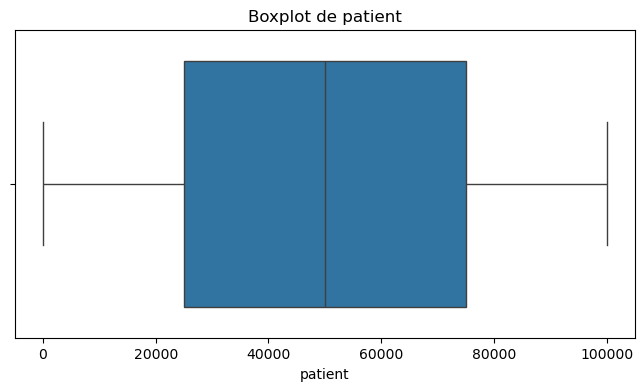

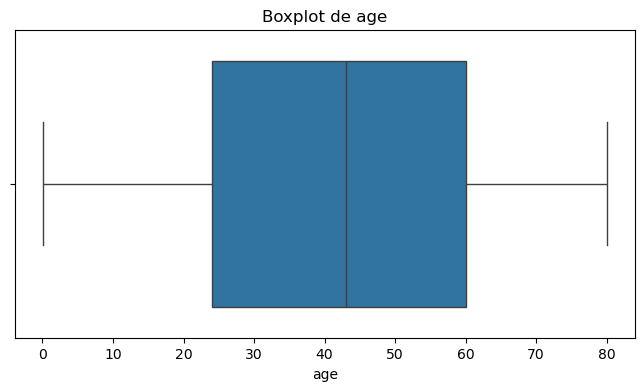

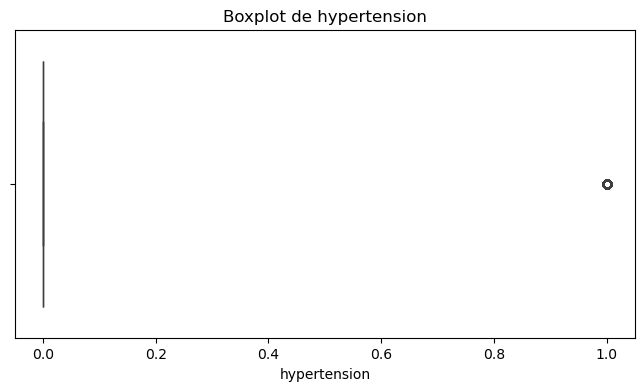

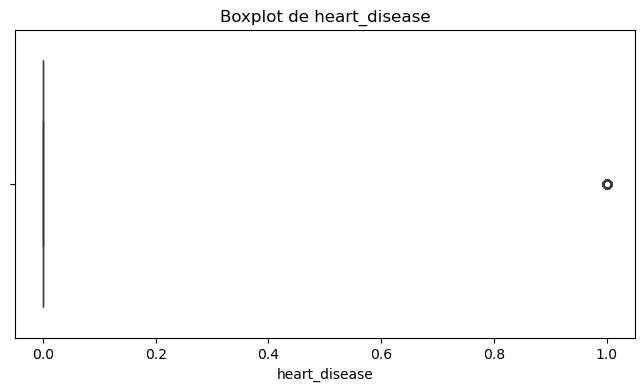

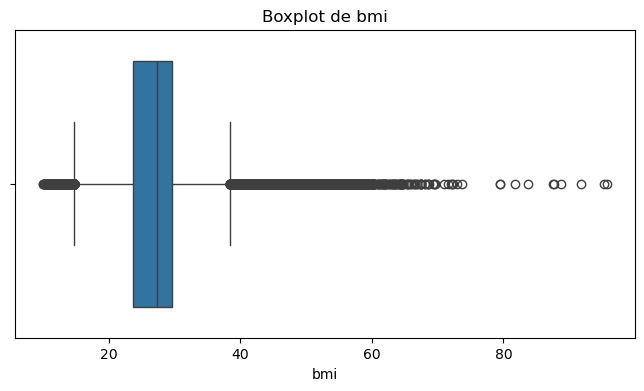

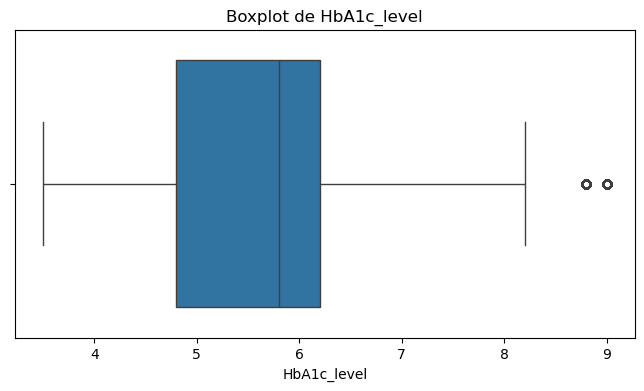

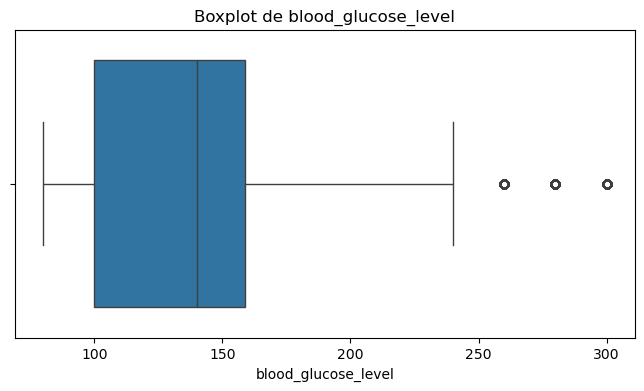

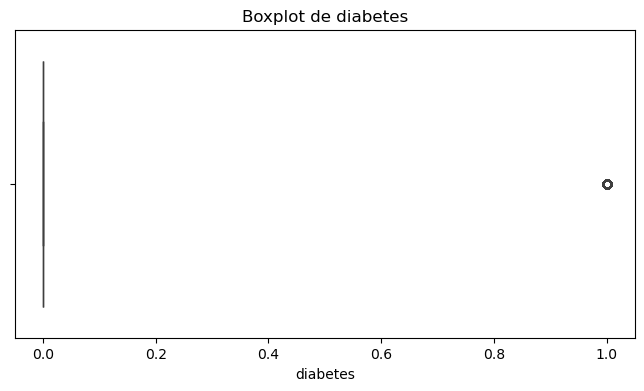

In [10]:
import seaborn as sns
# Selecciono solo columnas numéricas
numericas = train_df.select_dtypes(include='number').columns

# Genero boxplots uno por uno
for col in numericas:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=train_df[col])
    plt.title(f"Boxplot de {col}")
    plt.show()


Observamos la presencia de outliers significativos en la variable bmi, lo cual puede afectar negativamente en el desempeño de los algoritmos. 

Se propone segmentar la variable en grupos segun la clasificacion del indice de masa corporal. Menor a 18,5: de peso mas bajo que el normal ; entre 18,5 y 25: normal ; entre 25 y 29: sobrepeso; y mayor a 29:obesidad.

A su vez, variables como age tambien puede segmentarse, a rangos de tipo < 30 años: joven, <60 adulto, y mayor a 60 adulto mayor.


## Preprocesamiento de datos ##

### Análisis de datos faltantes

Una de nuestras variables categóricas (smoking_history) contiene una categoría que indica ausencia de información (No Info). Vamos a analizar cual es el porcentaje de faltante de informacion

In [11]:
train_df['smoking_history'].value_counts()['No Info']/train_df['smoking_history'].count()

0.35745263157894736

Esta categoría  'No Info' representa aproximadamente el 35 % de los registros. Debido a su alta frecuencia, y considerando que no aporta información clara sobre el comportamiento de la variable, se decide imputar estos valores con la categoría más frecuente del conjunto, con el objetivo de reducir el sesgo e inconsistencias en la codificación.

In [12]:
# Paso 1: Reemplazamos 'No Info' por NaN (tratarlo como valor faltante real)
train_df['smoking_history'] = np.where(train_df['smoking_history'] == 'No Info', np.nan, train_df['smoking_history'])

# Paso 2: Obtenemos la categoría más frecuente (moda), excluyendo NaNs
valor_mas_frecuente = train_df['smoking_history'].mode()[0]

# Paso 3: Imputar los valores faltantes con la moda
train_df['smoking_history'] = train_df['smoking_history'].fillna(valor_mas_frecuente)



In [13]:
train_df['smoking_history'].unique()

array(['never', 'former', 'current', 'not current', 'ever'], dtype=object)

Vamos a segmentar las variables antes mencionadas indice de masa corporal y edad

In [14]:
train_df_original = train_df.copy()  
train_df_bmi = train_df.copy()  
train_df_age = train_df.copy()  

In [15]:
def clasificar_bmi(bmi):
    if bmi < 18.5:
        return 'underweight'
    elif bmi < 25:
        return 'normal'
    elif bmi < 30:
        return 'overweight'
    else:
        return 'obese'

train_df['bmi_group'] = train_df['bmi'].apply(clasificar_bmi)
train_df.drop(columns=['bmi'], inplace=True)

train_df_bmi['bmi_group'] = train_df_bmi['bmi'].apply(clasificar_bmi)
train_df_bmi.drop(columns=['bmi'], inplace=True)


In [16]:
def clasificar_edad(age):
    if age < 30:
        return 'young'
    elif age < 60:
        return 'adult'
    else:
        return 'senior'

train_df['age_group'] = train_df['age'].apply(clasificar_edad)
train_df.drop(columns=['age'], inplace=True)

train_df_age['age_group'] = train_df_age['age'].apply(clasificar_edad)
train_df_age.drop(columns=['age'], inplace=True)

La variable patient es un identificador unico que no aporta nada al modelo, por lo cual lo eliminamos para el entrenamiento.

In [17]:
train_df.drop(columns=['patient'], inplace=True)
train_df_bmi.drop(columns=['patient'], inplace=True)
train_df_age.drop(columns=['patient'], inplace=True)
train_df_original.drop(columns=['patient'], inplace=True)


Aplicamos Onehotencoder a las variables categoricas y escalamos las numericas.

In [18]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler

def preprocesar_dataframe(df, target='diabetes', columnas_categoricas=None):
    if columnas_categoricas is None:
        posibles_cat = ['gender', 'smoking_history', 'bmi_group', 'age_group']
        columnas_categoricas = [col for col in posibles_cat if col in df.columns]
    
    # OneHotEncoder
    encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
    encoded_array = encoder.fit_transform(df[columnas_categoricas])
    encoded_cols = encoder.get_feature_names_out(columnas_categoricas)
    df_encoded = pd.DataFrame(encoded_array, columns=encoded_cols, index=df.index)

    # Escalar numéricas
    numeric_cols = df.drop(columns=columnas_categoricas + [target]).select_dtypes(include='number').columns.tolist()
    scaler = StandardScaler()
    scaled_array = scaler.fit_transform(df[numeric_cols])
    df_scaled = pd.DataFrame(scaled_array, columns=numeric_cols, index=df.index)

    # Combinar
    X = pd.concat([df_scaled, df_encoded], axis=1)
    y = df[target]
    
    return X, y, encoder, scaler




In [19]:
X_train_final_original, y_train_final_original, encoder_original, scaler_original = preprocesar_dataframe(
    train_df_original, columnas_categoricas=['gender', 'smoking_history']
)

X_train_final_bmi, y_train_final_bmi, encoder_bmi, scaler_bmi = preprocesar_dataframe(
    train_df_bmi, columnas_categoricas=['gender', 'smoking_history', 'bmi_group']
)

X_train_final_age, y_train_final_age, encoder_age, scaler_age = preprocesar_dataframe(
    train_df_age, columnas_categoricas=['gender', 'smoking_history', 'age_group']
)

X_train_final, y_train_final, encoder_bmi_age, scaler_bmi_age = preprocesar_dataframe(
    train_df, columnas_categoricas=['gender', 'smoking_history', 'bmi_group', 'age_group']
)



Aplicamos los pasos ya realizados para los datos de testeo.

In [20]:
def preprocesar_test(df_test, columnas_categoricas, encoder, scaler):
    df = df_test.copy()
    
    encoded_array = encoder.transform(df[columnas_categoricas])
    encoded_cols = encoder.get_feature_names_out(columnas_categoricas)
    df_encoded = pd.DataFrame(encoded_array, columns=encoded_cols, index=df.index)

    numeric_cols = scaler.feature_names_in_.tolist()
    scaled_array = scaler.transform(df[numeric_cols])
    df_scaled = pd.DataFrame(scaled_array, columns=numeric_cols, index=df.index)

    X_test = pd.concat([df_scaled, df_encoded], axis=1)
    return X_test



In [21]:
# Siempre reemplazar No Info y completar con la moda
test_df_clean = test_df.copy()
test_df_clean['smoking_history'] = np.where(
    test_df_clean['smoking_history'] == 'No Info',
    np.nan,
    test_df_clean['smoking_history']
)
test_df_clean['smoking_history'] = test_df_clean['smoking_history'].fillna(valor_mas_frecuente)
test_ids = test_df_clean['patient']





In [22]:
# Versión original
test_df_original = test_df_clean.drop(columns=['patient'])

# Versión BMI
test_df_bmi = test_df_clean.copy()
test_df_bmi['bmi_group'] = test_df_bmi['bmi'].apply(clasificar_bmi)
test_df_bmi.drop(columns=['bmi', 'patient'], inplace=True)

# Versión AGE
test_df_age = test_df_clean.copy()
test_df_age['age_group'] = test_df_age['age'].apply(clasificar_edad)
test_df_age.drop(columns=['age', 'patient'], inplace=True)

# Versión BMI + AGE
test_df_bmi_age = test_df_clean.copy()
test_df_bmi_age['bmi_group'] = test_df_bmi_age['bmi'].apply(clasificar_bmi)
test_df_bmi_age['age_group'] = test_df_bmi_age['age'].apply(clasificar_edad)
test_df_bmi_age.drop(columns=['bmi', 'age', 'patient'], inplace=True)


In [23]:
X_test_final_original = preprocesar_test(
    test_df_original, ['gender', 'smoking_history'], encoder_original, scaler_original
).reindex(columns=X_train_final_original.columns, fill_value=0)

X_test_final_bmi = preprocesar_test(
    test_df_bmi, ['gender', 'smoking_history', 'bmi_group'], encoder_bmi, scaler_bmi
).reindex(columns=X_train_final_bmi.columns, fill_value=0)

X_test_final_age = preprocesar_test(
    test_df_age, ['gender', 'smoking_history', 'age_group'], encoder_age, scaler_age
).reindex(columns=X_train_final_age.columns, fill_value=0)

X_test_final_bmi_age = preprocesar_test(
    test_df_bmi_age, ['gender', 'smoking_history', 'bmi_group', 'age_group'], encoder_bmi_age, scaler_bmi_age
).reindex(columns=X_train_final.columns, fill_value=0)


### Analizamos el balanceo de clases

In [24]:
# Conteo absoluto
print(train_df['diabetes'].value_counts())

# Porcentaje
print(train_df['diabetes'].value_counts(normalize=True) * 100)


diabetes
0    86918
1     8082
Name: count, dtype: int64
diabetes
0    91.492632
1     8.507368
Name: proportion, dtype: float64


Tenemos las clases altamente desbalanceadas lo cual es un problema porque muchos modelos tienden a predecir la clase mayoritaria para maximizar accuracy.
En este caso, un modelo que predice siempre "0" tendría ~91 % de accuracy, pero 0 % de recall para los positivos, lo cual es inaceptable ya que queremos detectar casos de diabetes

## Entrenamiento...

Dado que tenemos un alto desbalance de clases vamos a aplicar técnicas que permitan mejorar la capacidad del modelo para detectar casos positivos, sin quedar sesgado hacia la clase mayoritaria.

Se evaluarán dos estrategias ampliamente utilizadas:

class_weight='balanced', que ajusta internamente los pesos del modelo para penalizar más los errores sobre la clase minoritaria.

SMOTE, que genera ejemplos sintéticos de la clase minoritaria para balancear el dataset antes del entrenamiento.

#### Representaciones del dataset
Se utilizarán cuatro variantes del dataset, todas con variables categóricas codificadas mediante OneHotEncoder, para evaluar qué transformación de las variables bmi y age:
1. Dataset original.
2. Dataset con ambas variables categorizadas (bmi_group y age_group).
3. Dataset con variable bmi_group categorizada
4. Dataset con variable age_group categorizada

Al aplicar estas combinaciones, se busca determinar qué representación de los datos y qué técnica de balanceo conducen a mejorar el recall_score, métrica principal de la competencia, priorizando la detección de casos positivos de diabetes.



### OPCION 1: 
    Evaluamos los 4 dataset aplicando tecnicas de balanceo de clases

In [25]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import LinearSVC
from imblearn.over_sampling import SMOTE

# === Modelos ===
clfs_weight = [
    DecisionTreeClassifier(class_weight='balanced', random_state=8),
    RandomForestClassifier(class_weight='balanced', random_state=8),
    LogisticRegression(class_weight='balanced', max_iter=1000, random_state=8),
    LinearSVC(class_weight='balanced', max_iter=10000, random_state=8)
]
names_weight = [
    'Árbol de decisión (weight)',
    'Random Forest (weight)',
    'Regresión Logística (weight)',
    'SVM (weight)'
]

clfs_smote = [
    MLPClassifier(max_iter=500, random_state=8),
    XGBClassifier(random_state=8, use_label_encoder=False, eval_metric='logloss'),
    GaussianNB()
]
names_smote = [
    'Perceptrón Multicapa (SMOTE)',
    'XGBoost (SMOTE)',
    'Naive Bayes (SMOTE)'
]

# === Función para entrenar y evaluar ===
def entrenar_evaluar_modelos(modelos, nombres, X_train, y_train, X_val, y_val, titulo=''):
    print(f"\n Evaluando dataset: {titulo}")
    for clf, name in zip(modelos, nombres):
        clf.fit(X_train, y_train)
        preds = clf.predict(X_val)

        acc = accuracy_score(y_val, preds)
        precision = precision_score(y_val, preds)
        recall = recall_score(y_val, preds)
        f1 = f1_score(y_val, preds)

        print(f"\n Modelo: {name}")
        print(f"Accuracy : {acc * 100:.2f}%")
        print(f"Precision: {precision:.4f}")
        print(f"Recall   : {recall:.4f}")
        print(f"F1-score : {f1:.4f}")

# === Lista de datasets a evaluar ===
datasets = [
    ("Original", X_train_final_original, y_train_final_original),
    ("Solo BMI", X_train_final_bmi, y_train_final_bmi),
    ("Solo AGE", X_train_final_age, y_train_final_age),
    ("BMI + AGE", X_train_final, y_train_final)
]

# === Loop por dataset ===
for nombre, X_full, y_full in datasets:
    X_train, X_val, y_train, y_val = train_test_split(X_full, y_full, test_size=0.2, random_state=42)

    # Modelos con class_weight
    entrenar_evaluar_modelos(clfs_weight, names_weight, X_train, y_train, X_val, y_val, titulo=f"{nombre} (class_weight)")

    # Modelos que requieren SMOTE
    smote = SMOTE(random_state=42)
    X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)
    entrenar_evaluar_modelos(clfs_smote, names_smote, X_train_smote, y_train_smote, X_val, y_val, titulo=f"{nombre} (SMOTE)")



 Evaluando dataset: Original (class_weight)

 Modelo: Árbol de decisión (weight)
Accuracy : 95.36%
Precision: 0.7206
Recall   : 0.7323
F1-score : 0.7264

 Modelo: Random Forest (weight)
Accuracy : 96.96%
Precision: 0.9375
Recall   : 0.6848
F1-score : 0.7915

 Modelo: Regresión Logística (weight)
Accuracy : 88.59%
Precision: 0.4150
Recall   : 0.8693
F1-score : 0.5618

 Modelo: SVM (weight)
Accuracy : 88.67%
Precision: 0.4171
Recall   : 0.8699
F1-score : 0.5638

 Evaluando dataset: Original (SMOTE)

 Modelo: Perceptrón Multicapa (SMOTE)
Accuracy : 91.62%
Precision: 0.5013
Recall   : 0.8568
F1-score : 0.6325


/opt/anaconda3/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [21:00:38] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



 Modelo: XGBoost (SMOTE)
Accuracy : 96.92%
Precision: 0.9089
Recall   : 0.7048
F1-score : 0.7939

 Modelo: Naive Bayes (SMOTE)
Accuracy : 46.42%
Precision: 0.1346
Recall   : 0.9887
F1-score : 0.2370

 Evaluando dataset: Solo BMI (class_weight)

 Modelo: Árbol de decisión (weight)
Accuracy : 94.92%
Precision: 0.6854
Recall   : 0.7317
F1-score : 0.7078

 Modelo: Random Forest (weight)
Accuracy : 96.37%
Precision: 0.8379
Recall   : 0.7048
F1-score : 0.7656

 Modelo: Regresión Logística (weight)
Accuracy : 88.56%
Precision: 0.4144
Recall   : 0.8699
F1-score : 0.5613

 Modelo: SVM (weight)
Accuracy : 88.60%
Precision: 0.4153
Recall   : 0.8699
F1-score : 0.5622

 Evaluando dataset: Solo BMI (SMOTE)

 Modelo: Perceptrón Multicapa (SMOTE)
Accuracy : 91.26%
Precision: 0.4892
Recall   : 0.8605
F1-score : 0.6238


/opt/anaconda3/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [21:01:39] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



 Modelo: XGBoost (SMOTE)
Accuracy : 96.82%
Precision: 0.9067
Recall   : 0.6929
F1-score : 0.7855

 Modelo: Naive Bayes (SMOTE)
Accuracy : 40.13%
Precision: 0.1221
Recall   : 0.9875
F1-score : 0.2173

 Evaluando dataset: Solo AGE (class_weight)

 Modelo: Árbol de decisión (weight)
Accuracy : 94.55%
Precision: 0.6555
Recall   : 0.7436
F1-score : 0.6967

 Modelo: Random Forest (weight)
Accuracy : 96.08%
Precision: 0.8132
Recall   : 0.6942
F1-score : 0.7490

 Modelo: Regresión Logística (weight)
Accuracy : 88.55%
Precision: 0.4143
Recall   : 0.8724
F1-score : 0.5618

 Modelo: SVM (weight)
Accuracy : 88.73%
Precision: 0.4186
Recall   : 0.8718
F1-score : 0.5656

 Evaluando dataset: Solo AGE (SMOTE)

 Modelo: Perceptrón Multicapa (SMOTE)
Accuracy : 91.59%
Precision: 0.5002
Recall   : 0.8530
F1-score : 0.6306


/opt/anaconda3/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [21:02:51] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



 Modelo: XGBoost (SMOTE)
Accuracy : 96.59%
Precision: 0.8552
Recall   : 0.7167
F1-score : 0.7799

 Modelo: Naive Bayes (SMOTE)
Accuracy : 45.07%
Precision: 0.1295
Recall   : 0.9662
F1-score : 0.2284

 Evaluando dataset: BMI + AGE (class_weight)

 Modelo: Árbol de decisión (weight)
Accuracy : 92.03%
Precision: 0.5173
Recall   : 0.7967
F1-score : 0.6273

 Modelo: Random Forest (weight)
Accuracy : 93.57%
Precision: 0.5913
Recall   : 0.7636
F1-score : 0.6665

 Modelo: Regresión Logística (weight)
Accuracy : 88.44%
Precision: 0.4120
Recall   : 0.8749
F1-score : 0.5602

 Modelo: SVM (weight)
Accuracy : 88.49%
Precision: 0.4131
Recall   : 0.8724
F1-score : 0.5607

 Evaluando dataset: BMI + AGE (SMOTE)

 Modelo: Perceptrón Multicapa (SMOTE)
Accuracy : 91.12%
Precision: 0.4843
Recall   : 0.8480
F1-score : 0.6165


/opt/anaconda3/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [21:04:06] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



 Modelo: XGBoost (SMOTE)
Accuracy : 96.03%
Precision: 0.7774
Recall   : 0.7405
F1-score : 0.7585

 Modelo: Naive Bayes (SMOTE)
Accuracy : 43.90%
Precision: 0.1267
Recall   : 0.9619
F1-score : 0.2240


### OPCION 2: 
    Evaluamos los 4 dataset sin aplicar tecnicas de balanceo de clases

In [26]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import LinearSVC

# === Lista de modelos sin técnicas de balanceo ===
clfs = [
    DecisionTreeClassifier(random_state=8),
    RandomForestClassifier(random_state=8),
    LogisticRegression(max_iter=1000, random_state=8),
    MLPClassifier(max_iter=500, random_state=8),
    XGBClassifier(random_state=8, use_label_encoder=False, eval_metric='logloss'),
    GaussianNB(),
    LinearSVC(max_iter=10000, random_state=8)
]

names = [
    'Árbol de decisión',
    'Random Forest',
    'Regresión Logística',
    'Perceptrón Multicapa',
    'XGBoost',
    'Naive Bayes',
    'SVM'
]

# === Función general para entrenar y evaluar ===
def entrenar_evaluar_modelos_sin_balanceo(modelos, nombres, X_train, y_train, X_val, y_val, titulo=''):
    print(f"\n Evaluando dataset: {titulo}")
    for clf, name in zip(modelos, nombres):
        clf.fit(X_train, y_train)
        preds = clf.predict(X_val)

        acc = accuracy_score(y_val, preds)
        precision = precision_score(y_val, preds)
        recall = recall_score(y_val, preds)
        f1 = f1_score(y_val, preds)

        print(f"\n Modelo: {name}")
        print(f"Accuracy : {acc * 100:.2f}%")
        print(f"Precision: {precision:.4f}")
        print(f"Recall   : {recall:.4f}")
        print(f"F1-score : {f1:.4f}")

# === Lista de datasets a evaluar ===
datasets = [
    ("Original", X_train_final_original, y_train_final_original),
    ("Solo BMI", X_train_final_bmi, y_train_final_bmi),
    ("Solo AGE", X_train_final_age, y_train_final_age),
    ("BMI + AGE", X_train_final, y_train_final)
]

# === Loop por cada dataset ===
for nombre, X_full, y_full in datasets:
    X_train, X_val, y_train, y_val = train_test_split(X_full, y_full, test_size=0.2, random_state=42)
    entrenar_evaluar_modelos_sin_balanceo(clfs, names, X_train, y_train, X_val, y_val, titulo=nombre)



 Evaluando dataset: Original

 Modelo: Árbol de decisión
Accuracy : 95.35%
Precision: 0.7203
Recall   : 0.7311
F1-score : 0.7256

 Modelo: Random Forest
Accuracy : 96.98%
Precision: 0.9460
Recall   : 0.6798
F1-score : 0.7911

 Modelo: Regresión Logística
Accuracy : 96.03%
Precision: 0.8644
Recall   : 0.6260
F1-score : 0.7262

 Modelo: Perceptrón Multicapa
Accuracy : 97.17%
Precision: 0.9749
Recall   : 0.6811
F1-score : 0.8019


/opt/anaconda3/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [21:04:16] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



 Modelo: XGBoost
Accuracy : 97.18%
Precision: 0.9594
Recall   : 0.6942
F1-score : 0.8055

 Modelo: Naive Bayes
Accuracy : 64.08%
Precision: 0.1859
Recall   : 0.9669
F1-score : 0.3118

 Modelo: SVM
Accuracy : 96.08%
Precision: 0.8954
Recall   : 0.6048
F1-score : 0.7219

 Evaluando dataset: Solo BMI

 Modelo: Árbol de decisión
Accuracy : 95.53%
Precision: 0.7376
Recall   : 0.7280
F1-score : 0.7328

 Modelo: Random Forest
Accuracy : 96.71%
Precision: 0.8859
Recall   : 0.6992
F1-score : 0.7815

 Modelo: Regresión Logística
Accuracy : 96.01%
Precision: 0.8672
Recall   : 0.6210
F1-score : 0.7238

 Modelo: Perceptrón Multicapa
Accuracy : 97.12%
Precision: 0.9870
Recall   : 0.6667
F1-score : 0.7958


/opt/anaconda3/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [21:04:29] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



 Modelo: XGBoost
Accuracy : 97.17%
Precision: 0.9741
Recall   : 0.6817
F1-score : 0.8021

 Modelo: Naive Bayes
Accuracy : 55.11%
Precision: 0.1549
Recall   : 0.9731
F1-score : 0.2673

 Modelo: SVM
Accuracy : 96.01%
Precision: 0.8962
Recall   : 0.5941
F1-score : 0.7146

 Evaluando dataset: Solo AGE

 Modelo: Árbol de decisión
Accuracy : 95.36%
Precision: 0.7230
Recall   : 0.7280
F1-score : 0.7255

 Modelo: Random Forest
Accuracy : 96.65%
Precision: 0.8874
Recall   : 0.6898
F1-score : 0.7762

 Modelo: Regresión Logística
Accuracy : 95.96%
Precision: 0.8624
Recall   : 0.6191
F1-score : 0.7208

 Modelo: Perceptrón Multicapa
Accuracy : 97.13%
Precision: 0.9774
Recall   : 0.6748
F1-score : 0.7984


/opt/anaconda3/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [21:04:42] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



 Modelo: XGBoost
Accuracy : 97.09%
Precision: 0.9564
Recall   : 0.6854
F1-score : 0.7985

 Modelo: Naive Bayes
Accuracy : 58.20%
Precision: 0.1629
Recall   : 0.9587
F1-score : 0.2785

 Modelo: SVM
Accuracy : 95.98%
Precision: 0.8884
Recall   : 0.5972
F1-score : 0.7143

 Evaluando dataset: BMI + AGE

 Modelo: Árbol de decisión
Accuracy : 96.56%
Precision: 0.8650
Recall   : 0.7011
F1-score : 0.7744

 Modelo: Random Forest
Accuracy : 96.62%
Precision: 0.8813
Recall   : 0.6917
F1-score : 0.7751

 Modelo: Regresión Logística
Accuracy : 95.95%
Precision: 0.8640
Recall   : 0.6160
F1-score : 0.7192

 Modelo: Perceptrón Multicapa
Accuracy : 97.01%
Precision: 0.9533
Recall   : 0.6773
F1-score : 0.7920


/opt/anaconda3/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [21:04:57] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



 Modelo: XGBoost
Accuracy : 97.04%
Precision: 0.9544
Recall   : 0.6804
F1-score : 0.7945

 Modelo: Naive Bayes
Accuracy : 52.15%
Precision: 0.1453
Recall   : 0.9600
F1-score : 0.2524

 Modelo: SVM
Accuracy : 95.94%
Precision: 0.8919
Recall   : 0.5885
F1-score : 0.7091


Se observa que los modelos con mejor capacidad para identificar correctamente la clase positiva (mayor Recall) son:

Naive Bayes 

SVM 

Regresión Logística 

Aunque algunos modelos como XGBoost o MLP tienen mejor F1-score, su recall es más bajo. Dado que el objetivo principal es maximizar el recall, priorizamos modelos que lo optimicen, incluso a costa de precisión.

Pequeño cuadro comparativo
| Modelo                  | Recall Original | Recall BMI | Recall AGE | Recall BMI+AGE |
| ----------------------- | --------------- | ---------- | ---------- | -------------- |
| **Naive Bayes** | **0.9887**      | 0.9875     | 0.9662     | 0.9619         |
| **SVM**        | **0.8699**      | 0.8605     | 0.8530     | 0.8480         |
| Reg. Logística  | 0.8693          | 0.8574     | 0.8511     | 0.8436         |
| XGBoost          | 0.7048          | 0.6929     | 0.7167     | 0.7405         |
| Random Forest | 0.6848          | 0.7048     | 0.6942     | 0.7636         |
| MLPClassifier           | 0.6811          | 0.6667     | 0.6748     | 0.6773         |


El siguiente paso es el ajuste hiperparametros, para ello decidimos trabajar con:

1. SVM 

- Mejor modelo equilibrado con recall alto (0.8699)

- Se probará sobre df_Original y df_BMI

- Hiperparámetros a ajustar: C, kernel, gamma, class_weight

2. Regresión Logística

- Se probará sobre df_Original y df_AGE

- Hiperparámetros a ajustar: C, penalty, solver, class_weight

3. Naive Bayes 

- Máximo recall alcanzado (0.9887)

- Pese a su baja precisión, es útil cuando lo crítico es detectar todos los positivos

- Se probará solo en df_Original


### Lo hacemos aplicando tecnicas de balanceo de clase?
SVM
| Dataset  | Recall con balanceo (weight) | Recall sin balanceo |
| -------- | ---------------------------- | ------------------- |
| Original | **0.8699**                   | 0.6048              |
| BMI      | **0.8605**                   | 0.5941              |
| AGE      | **0.8530**                   | 0.5972              |
| BMI+AGE  | **0.8480**                   | 0.5885              |


Regresion Logistica
| Dataset  | Recall con balanceo (weight) | Recall sin balanceo |
| -------- | ---------------------------- | ------------------- |
| Original | **0.8693**                   | 0.6260              |
| BMI      | **0.8574**                   | 0.6339              |
| AGE      | **0.8511**                   | 0.6408              |
| BMI+AGE  | **0.8436**                   | 0.6346              |

Naive Bayes (SMOTE)

| Dataset  | Recall con SMOTE | Recall sin balanceo |
| -------- | ---------------- | ------------------- |
| Original | **0.9887**       | 0.9669              |
| BMI      | **0.9875**       | 0.9731              |
| AGE      | **0.9662**       | 0.9587              |
| BMI+AGE  | **0.9619**       | 0.9600              |



## Ajuste de Hiperparámetros

### SVM para el df original y con tecnica de balanceo de clase

In [27]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, make_scorer, recall_score
from sklearn.pipeline import Pipeline

# Dataset a usar
X_train, y_train = X_train_final_original, y_train_final_original

# Pipeline con escalado
pipeline_svm = Pipeline([
    ("classifier", SVC(class_weight='balanced'))
])

# Definimos la grilla de hiperparámetros
param_grid_svm = {
    "classifier__C": [0.01, 0.1, 1, 10],
    "classifier__kernel": ["linear", "rbf", "poly"],
    "classifier__gamma": ["scale", "auto"]
}

# Optimizamos Recall
grid_search_svm = GridSearchCV(
    pipeline_svm,
    param_grid=param_grid_svm,
    scoring=make_scorer(recall_score),
    cv=5,
    n_jobs=-1,
    verbose=1
)

# Entrenamiento
grid_search_svm.fit(X_train, y_train)

# Resultados
print("Mejor Recall:", grid_search_svm.best_score_)
print("Mejores parámetros:", grid_search_svm.best_params_)

# Modelo final
mejor_modelo_svm_org = grid_search_svm.best_estimator_




Fitting 5 folds for each of 24 candidates, totalling 120 fits
Mejor Recall: 0.9221736714487776
Mejores parámetros: {'classifier__C': 10, 'classifier__gamma': 'scale', 'classifier__kernel': 'poly'}


### SVM para el df con segmentacion del indice de masa corporal y con tecnica de balanceo de clase

In [28]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, make_scorer, recall_score
from sklearn.pipeline import Pipeline

# Dataset a usar
X_train, y_train = X_train_final_bmi, y_train_final_bmi

# Pipeline con escalado
pipeline_svm = Pipeline([
    ("classifier", SVC(class_weight='balanced'))
])

# Definimos la grilla de hiperparámetros
param_grid_svm = {
    "classifier__C": [0.01, 0.1, 1, 10],
    "classifier__kernel": ["linear", "rbf", "poly"],
    "classifier__gamma": ["scale", "auto"]
}

# Optimizamos Recall
grid_search_svm = GridSearchCV(
    pipeline_svm,
    param_grid=param_grid_svm,
    scoring=make_scorer(recall_score),
    cv=5,
    n_jobs=-1,
    verbose=1
)

# Entrenamiento
grid_search_svm.fit(X_train, y_train)

# Resultados
print("Mejor Recall:", grid_search_svm.best_score_)
print("Mejores parámetros:", grid_search_svm.best_params_)

# Modelo final
mejor_modelo_svm = grid_search_svm.best_estimator_

Fitting 5 folds for each of 24 candidates, totalling 120 fits


/opt/anaconda3/lib/python3.12/site-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Mejor Recall: 0.9195751207773839
Mejores parámetros: {'classifier__C': 1, 'classifier__gamma': 'scale', 'classifier__kernel': 'rbf'}


Con el ajuste de hiperparametros sobre el df original mejoramos el recall de 0.8699 a 0.9221. Sobre el df_bmi tambien logramos mejorar de 0.8605 a 0.9195

### Regresion logistica para el df original y con tecnica de balanceo de clase

In [29]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import recall_score, make_scorer
from sklearn.pipeline import Pipeline


# Dataset a usar
X_train, y_train = X_train_final_original, y_train_final_original

# Pipeline con escalado
pipeline_logreg = Pipeline([
    ("classifier", LogisticRegression(class_weight='balanced', max_iter=1000))
])

# Grilla de hiperparámetros
param_grid_logreg = {
    "classifier__C": [0.01, 0.1, 1, 10],
    "classifier__penalty": ["l2"],
    "classifier__solver": ["lbfgs", "liblinear"]
}

# GridSearch optimizando Recall
grid_search_logreg = GridSearchCV(
    pipeline_logreg,
    param_grid=param_grid_logreg,
    scoring=make_scorer(recall_score),
    cv=5,
    n_jobs=-1,
    verbose=1
)

# Entrenamiento
grid_search_logreg.fit(X_train, y_train)

# Resultados
print("Mejor Recall:", grid_search_logreg.best_score_)
print("Mejores parámetros:", grid_search_logreg.best_params_)

# Modelo final
mejor_modelo_logreg_org = grid_search_logreg.best_estimator_


Fitting 5 folds for each of 8 candidates, totalling 40 fits
Mejor Recall: 0.8805991568544611
Mejores parámetros: {'classifier__C': 0.01, 'classifier__penalty': 'l2', 'classifier__solver': 'liblinear'}


### Regresion logistica para el df age y con tecnica de balanceo de clase

In [30]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import recall_score, make_scorer
from sklearn.pipeline import Pipeline


# Dataset a usar
X_train, y_train = X_train_final_age, y_train_final_age

# Pipeline con escalado
pipeline_logreg = Pipeline([
    ("classifier", LogisticRegression(class_weight='balanced', max_iter=1000))
])

# Grilla de hiperparámetros
param_grid_logreg = {
    "classifier__C": [0.01, 0.1, 1, 10],
    "classifier__penalty": ["l2"],
    "classifier__solver": ["lbfgs", "liblinear"]
}

# GridSearch optimizando Recall
grid_search_logreg = GridSearchCV(
    pipeline_logreg,
    param_grid=param_grid_logreg,
    scoring=make_scorer(recall_score),
    cv=5,
    n_jobs=-1,
    verbose=1
)

# Entrenamiento
grid_search_logreg.fit(X_train, y_train)

# Resultados
print("Mejor Recall:", grid_search_logreg.best_score_)
print("Mejores parámetros:", grid_search_logreg.best_params_)

# Modelo final
mejor_modelo_logreg = grid_search_logreg.best_estimator_


Fitting 5 folds for each of 8 candidates, totalling 40 fits
Mejor Recall: 0.8757735722551846
Mejores parámetros: {'classifier__C': 0.1, 'classifier__penalty': 'l2', 'classifier__solver': 'liblinear'}


Con el ajuste de hiperparametros sobre el df original mejoramos el recall de 0.8693 a 0.8805. Sobre el df_age tambien logramos mejorar de 0.8511 a 0.8757

### Naive Bayes sobre df original y con tecnica de balanceo de clase

In [31]:
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import cross_val_score
from sklearn.metrics import make_scorer, recall_score

# Dataset original sin balancear
X_train, y_train = X_train_final_original, y_train_final_original

# Pipeline con SMOTE + Naive Bayes
pipeline_nb = ImbPipeline([
    ("smote", SMOTE(random_state=42)),
    ("nb", GaussianNB())
])

# Evaluamos con validación cruzada usando Recall
recall_scores = cross_val_score(
    pipeline_nb,
    X_train,
    y_train,
    scoring=make_scorer(recall_score),
    cv=5,
    n_jobs=-1
)

print("Recall promedio (CV):", recall_scores.mean())
print("Recall por fold:", recall_scores)


Recall promedio (CV): 0.9919574355394722
Recall por fold: [0.99319307 0.99071782 0.99195545 0.99072356 0.99319728]


Con escalado

In [32]:
from sklearn.preprocessing import MinMaxScaler

pipeline_nb_scaled = ImbPipeline([
    ("scaler", MinMaxScaler()),
    ("smote", SMOTE(random_state=42)),
    ("nb", GaussianNB())
])

recall_scores_scaled = cross_val_score(
    pipeline_nb_scaled,
    X_train,
    y_train,
    scoring=make_scorer(recall_score),
    cv=5,
    n_jobs=-1
)

print("Recall promedio con escalado:", recall_scores_scaled.mean())


Recall promedio con escalado: 0.9952981012386953


CONCLUSION: El maximo recall lo obtenemos con Naive Bayes pero se sacrifica mucha precision, de todas maneras nos quedamos con este modelo porque el objetivo es identificar pacientes con diabetes, lo mas importante es no dejar pasar los casos positivos, incluso si eso implica aumentar el numero de falsos positivos.

### Generamos la salida

In [33]:
from imblearn.over_sampling import SMOTE
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import MinMaxScaler
import pandas as pd
import numpy as np

# Escalar X_train y X_test
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train_final_original)
X_test_scaled = scaler.transform(X_test_final_original)

# Aplicar SMOTE sobre X_train escalado
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_train_scaled, y_train_final_original)

# Entrenar modelo sobre datos escalados y balanceados
nb = GaussianNB()
nb.fit(X_resampled, y_resampled)

# Predecir sobre el test escalado
y_pred_test_nb = nb.predict(X_test_scaled)

# Crear archivo de submission
submission_nb = pd.DataFrame({
    "patient": test_ids,
    "diabetes": np.int64(y_pred_test_nb)
})

submission_nb.to_csv("submission_nb.csv", index=False)
print("submission_nb.csv creado.")
display(submission_nb.head())


submission_nb.csv creado.


,patient,diabetes
0,49267,1
1,82280,0
2,33216,1
3,94551,1
4,43760,1
